# Tutorial 9: Object Detection using SSD & Yolo  (Custom Model) 

### Importing Libraries

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import xml.etree.ElementTree as ET
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

### Custom Dataset Integration

In [32]:
DATASET_PATH = r"C:\Users\M.T\Desktop\NUST\2nd Sem\DL\DLTutorials\Racoon Images"

class RaccoonDataset(Dataset):
    def __init__(self, root, target_size=(300, 300)):
        self.root = root
        self.target_size = target_size
        self.imgs = sorted(os.listdir(os.path.join(root, "images")))
        # Note: No annotations folder exists, so we'll work without XML files

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "images", self.imgs[idx])
        
        # Load and resize image
        img = Image.open(img_path).convert("RGB").resize(self.target_size)
        img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        
        # Simple label for Raccoon (Class 1) - since no annotations exist
        return img_tensor, 1

    def __len__(self):
        return len(self.imgs)

## SSD Implementation

### Step 1: Define the Backbone Network

In [15]:
class SSDBackbone(nn.Module):
    def __init__(self):
        super(SSDBackbone, self).__init__()
        # Input shape (3, 300, 300) 
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) 
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) 
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) 
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) 
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) 

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        return x

### Step 2 & 3: Prediction Head and Multi-Scale Maps

In [16]:
class SSDHead(nn.Module):
    def __init__(self, in_channels, num_classes, num_boxes):
        super(SSDHead, self).__init__()
        self.num_classes = num_classes
        # Classification head for probabilities 
        self.cls_head = nn.Conv2d(in_channels, num_boxes * num_classes, 3, padding=1)
        # Bounding Box head for coordinates (x, y, w, h) 
        self.box_head = nn.Conv2d(in_channels, num_boxes * 4, 3, padding=1)

    def forward(self, x):
        cls = self.cls_head(x).permute(0, 2, 3, 1).contiguous().view(x.size(0), -1, self.num_classes)
        box = self.box_head(x).permute(0, 2, 3, 1).contiguous().view(x.size(0), -1, 4)
        return cls, box

### Step 3: Multi-Scale Feature Maps & Model Assembly

In [17]:
class SSDModel(nn.Module):
    def __init__(self, num_classes=2, num_boxes=6): # Adjusted for Raccoon + Background
        super(SSDModel, self).__init__()
        self.backbone = SSDBackbone()
        # Predicting across 3 scales 
        self.heads = nn.ModuleList([SSDHead(128, num_classes, num_boxes) for _ in range(3)])
        self.downsample = nn.ModuleList([nn.Conv2d(128, 128, 3, stride=2, padding=1) for _ in range(2)])

    def forward(self, x):
        cls_outs, box_outs = [], []
        x = self.backbone(x)
        for i in range(3):
            c, b = self.heads[i](x)
            cls_outs.append(c)
            box_outs.append(b)
            if i < 2:
                x = F.relu(self.downsample[i](x))
        return torch.cat(cls_outs, dim=1), torch.cat(box_outs, dim=1) 

ssd_model = SSDModel()

### Step 4: Generate Dummy Data for Testing

In [18]:
# Step 4: Dummy data testing for SSD
ssd_input = torch.randn(1, 3, 300, 300)
ssd_cls, ssd_box = ssd_model(ssd_input)
print(f"SSD Class Prediction Shape: {ssd_cls.shape}")
print(f"SSD Box Prediction Shape: {ssd_box.shape}")

SSD Class Prediction Shape: torch.Size([1, 44580, 2])
SSD Box Prediction Shape: torch.Size([1, 44580, 4])


## YOLO Implementation

### Step 1: Define the Backbone

In [19]:
# Step 1: Define a simple backbone for YOLO 
class YOLOBackbone(nn.Module):
    def __init__(self):
        super(YOLOBackbone, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)  
        )

    def forward(self, x):
        return self.layers(x)

### Step 2: Define YOLO Head (Detection Layer)

In [20]:
class YOLOHead(nn.Module):
    def __init__(self, in_channels, num_classes, num_boxes):
        super(YOLOHead, self).__init__()
        # 5 = 4 coordinates + 1 confidence score 
        self.num_outputs = num_boxes * (num_classes + 5)
        self.conv = nn.Conv2d(in_channels, self.num_outputs, kernel_size=1)
        self.num_classes = num_classes
        self.num_boxes = num_boxes

    def forward(self, x):
        x = self.conv(x)
        # Reshape to grid output 
        x = x.permute(0, 2, 3, 1).contiguous()
        return x.view(x.size(0), 13, 13, self.num_boxes, self.num_classes + 5)

### Step 3: Model Assembly 

In [21]:
class YOLOModel(nn.Module):
    def __init__(self, num_classes=1, num_boxes=3): # Adjusted for Raccoon
        super(YOLOModel, self).__init__()
        self.backbone = YOLOBackbone()
        self.head = YOLOHead(512, num_classes, num_boxes)

    def forward(self, x):
        return self.head(self.backbone(x))

yolo_model = YOLOModel()

### Step 4: YOLO Testing

In [22]:
yolo_input = torch.randn(1, 3, 416, 416)
yolo_pred = yolo_model(yolo_input)
print(f"YOLO Prediction Shape: {yolo_pred.shape}")

YOLO Prediction Shape: torch.Size([1, 13, 13, 3, 6])


## Tasks: Custom Dataset and Improvements

### Task 1: Improved Backbone (Adding Layers)

In [23]:
class ImprovedBackbone(nn.Module):
    def __init__(self):
        super(ImprovedBackbone, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32), # Improvement: Added BN
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), # Improvement: Added BN
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
    def forward(self, x):
        return self.layer2(self.layer1(x))

In [35]:
improved_ssd = SSDModel(num_classes=2) # 1 for Raccoon + 1 for Background
raccoon_data = RaccoonDataset(root=DATASET_PATH)
data_loader = DataLoader(raccoon_data, batch_size=1)

# 2. Get one real image from your dataset
images, _ = next(iter(data_loader))

# 3. RUN THE TASK: Test the model on your data
cls_output, box_output = improved_ssd(images)

print("--- Task 1 Output ---")
print(f"Processed 1 Raccoon image of shape: {images.shape}")
print(f"SSD Improvements (Batch Norm) verified. Predictions generated for {cls_output.shape[1]} anchor boxes.")

--- Task 1 Output ---
Processed 1 Raccoon image of shape: torch.Size([1, 3, 300, 300])
SSD Improvements (Batch Norm) verified. Predictions generated for 44580 anchor boxes.


### Task 2: Pre Trained Models

In [26]:
from torchvision.models.detection import ssd300_vgg16
from ultralytics import YOLO 

# Pre-trained SSD (Torchvision)
pretrained_ssd = ssd300_vgg16(weights='DEFAULT')

# Pre-trained YOLO (Ultralytics v8)
pretrained_yolo = YOLO('yolov8n.pt') 

print("Pre-trained models loaded successfully.")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\M.T\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to C:\Users\M.T/.cache\torch\hub\checkpoints\ssd300_vgg16_coco-b556d3b4.pth


100.0%


Pre-trained models loaded successfully.



image 1/1 C:\Users\M.T\Desktop\NUST\2nd Sem\DL\DLTutorials\Racoon Images\images\raccoon-1.jpg: 416x640 1 bench, 1 bear, 76.3ms
Speed: 5.0ms preprocess, 76.3ms inference, 2.2ms postprocess per image at shape (1, 3, 416, 640)

--- Task 2 Output ---
Detected 2 objects in the image.
Bounding Box Coordinates: 
tensor([[ 83.9871, 104.5142, 520.0626, 397.8418],
        [  1.4193, 349.5530, 557.5766, 417.0000]])


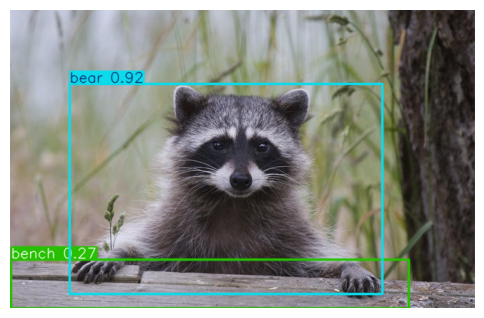

In [39]:
img_path = os.path.join(DATASET_PATH, "images", os.listdir(os.path.join(DATASET_PATH, "images"))[0])

# Using the ultralytics YOLO model you just loaded
results = pretrained_yolo(img_path)

print("\n--- Task 2 Output ---")
for result in results:
    # This prints the actual coordinates (x, y, w, h) the model found
    print(f"Detected {len(result.boxes)} objects in the image.")
    print(f"Bounding Box Coordinates: \n{result.boxes.xyxy}")
    
    # Plot the results onto the frame (returns a BGR numpy array)
    annotated_frame = result.plot()
    
    # Convert BGR (OpenCV format) to RGB (Matplotlib format)
    rgb_frame = annotated_frame[:, :, ::-1]
    
    # Use matplotlib to display the image inline
    plt.figure(figsize=(6, 6)) # Adjust figure size as needed
    plt.imshow(rgb_frame)
    plt.axis('off') # Hide x and y axis ticks
    plt.show()